In [1]:
import pandas as pd
import yaml
import os
import matplotlib.pyplot as plt 
import seaborn as sns
import os
import yaml
import os.path as op
import scanpy as sc
import numpy as np


In [36]:
def read_all_results(root_dir, select = ('overlaps_global_top_k.tsv')):
    """
    Reads all YAML files in a tree of directories starting from root_dir.extended
    Args: 
        root_dir (str): The path to the root directory.

    Returns:
        list: A list of dictionaries, where each dictionary represents the
              content of a YAML file.
    """
    all_results = []
    
    # Normalize the root_dir path
    root_dir = os.path.abspath(root_dir)

    # Check if the root directory exists
    if not os.path.isdir(root_dir):
        print(f"Error: Directory '{root_dir}' not found.")
        return all_results

    for dirpath, dirnames, filenames in os.walk(root_dir):
        for filename in filenames:
            if filename.endswith(select) :

                filepath = os.path.join(dirpath, filename)
                try:
                    overlaps = pd.read_csv(filepath, sep = '\t', index_col=0)
                    overlaps['dataset'] = op.basename(op.dirname(filepath))
                    all_results.append(overlaps)
                except:
                    continue
    all_results = pd.concat(all_results)

                    
    return all_results

In [40]:
res = read_all_results('/data_nfs/og86asub/netmap/netmap-evaluation/results/summaries_new/',  select = ('overlaps_global_top_k.tsv'))
split_data = res['method'].str.split('_', expand=True)
split_data.columns = ['xai_method', 'hidden_layer_size', 'n_hidden_layers', 'dropout', 'model', 'background']
res = pd.concat([res, split_data], axis=1)
res.to_csv('/data_nfs/og86asub/netmap/netmap-evaluation/results/summaries_new/combined_overlaps_global_top_k.tsv', sep='\t')


In [41]:
res = read_all_results('/data_nfs/og86asub/netmap/netmap-evaluation/results/summaries_new/',  select = ('area_over_diagnoal.tsv'))
split_data = res['method'].str.split('_', expand=True)
split_data.columns = ['xai_method', 'hidden_layer_size', 'n_hidden_layers', 'dropout', 'model', 'background']
res = pd.concat([res, split_data], axis=1)
res.to_csv('/data_nfs/og86asub/netmap/netmap-evaluation/results/summaries_new/combined_overlaps_global_top_k.tsv', sep = '\t')



In [39]:
res

,net,target,direction,method,net_type,layer,Area Over Diagonal,dataset,xai_method,hidden_layer_size,n_hidden_layers,dropout,model,background
0,net_84_10865,off_target,forward,GuidedBackprop_32_1_0.1_ZINBAutoencoder_zeros,strict,X,-0.065700,net_84_10865_net_88_10937_net_90_11013,GuidedBackprop,32,1,0.1,ZINBAutoencoder,zeros
1,net_84_10865,off_target,reverse,GuidedBackprop_32_1_0.1_ZINBAutoencoder_zeros,strict,X,-0.067990,net_84_10865_net_88_10937_net_90_11013,GuidedBackprop,32,1,0.1,ZINBAutoencoder,zeros
2,net_84_10865,on_target,forward,GuidedBackprop_32_1_0.1_ZINBAutoencoder_zeros,strict,X,0.106227,net_84_10865_net_88_10937_net_90_11013,GuidedBackprop,32,1,0.1,ZINBAutoencoder,zeros
3,net_84_10865,on_target,reverse,GuidedBackprop_32_1_0.1_ZINBAutoencoder_zeros,strict,X,0.197316,net_84_10865_net_88_10937_net_90_11013,GuidedBackprop,32,1,0.1,ZINBAutoencoder,zeros
4,net_88_10937,off_target,forward,GuidedBackprop_32_1_0.1_ZINBAutoencoder_zeros,strict,X,-0.101809,net_84_10865_net_88_10937_net_90_11013,GuidedBackprop,32,1,0.1,ZINBAutoencoder,zeros
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7,net_88_10937,on_target,reverse,Deconvolution_32_1_0.1_NegativeBinomialAutoenc...,strict,X,0.033664,net_84_10865_net_88_10937_net_90_11013,Deconvolution,32,1,0.1,NegativeBinomialAutoencoder,zeros
8,net_90_11013,off_target,forward,Deconvolution_32_1_0.1_NegativeBinomialAutoenc...,unspecific,X,0.103552,net_84_10865_net_88_10937_net_90_11013,Deconvolution,32,1,0.1,NegativeBinomialAutoencoder,zeros
9,net_90_11013,off_target,reverse,Deconvolution_32_1_0.1_NegativeBinomialAutoenc...,unspecific,X,0.061305,net_84_10865_net_88_10937_net_90_11013,Deconvolution,32,1,0.1,NegativeBinomialAutoencoder,zeros
10,net_90_11013,on_target,forward,Deconvolution_32_1_0.1_NegativeBinomialAutoenc...,unspecific,X,0.056820,net_84_10865_net_88_10937_net_90_11013,Deconvolution,32,1,0.1,NegativeBinomialAutoencoder,zeros


In [13]:
res.n_hidden_layers.unique()

array(['1', '2', '3'], dtype=object)

In [221]:
# Create a color map for the 'Method' column
unique_methods = res2['Method'].unique()
colors = sns.color_palette("husl", len(unique_methods))
method_color_map = dict(zip(unique_methods, colors))


In [222]:

# Create the annotation dataframe for the row_colors parameter
row_annotations = pd.DataFrame({
    'Method_Col': resagg.index.map(method_color_map),
    # You can add more mappings for Size or Model here
    
})

In [226]:
resagg

,Area Over Diagonal
method,
Deconvolution_32_1_0.1_NegativeBinomialAutoencoder_zeros,0.013962
Deconvolution_32_1_0_NegativeBinomialAutoencoder_zeros,-0.000127
Deconvolution_32_1_0_ZINBAutoencoder_zeros,-0.053744
Deconvolution_64_1_0.1_NegativeBinomialAutoencoder,0.052701
Deconvolution_64_1_0.1_ZINBAutoencoder,0.015133
Deconvolution_64_1_0_NegativeBinomialAutoencoder,-0.031220
Deconvolution_64_1_0_ZINBAutoencoder,-0.040587
Deconvolution_64_2_0.1_ZINBAutoencoder,-0.033286
Deconvolution_64_2_0_ZINBAutoencoder,-0.075548


/data_nfs/og86asub/netmap/netmap-evaluation/netmap/.pixi/envs/default/lib/python3.12/site-packages/seaborn/matrix.py:1113: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(**tight_params)


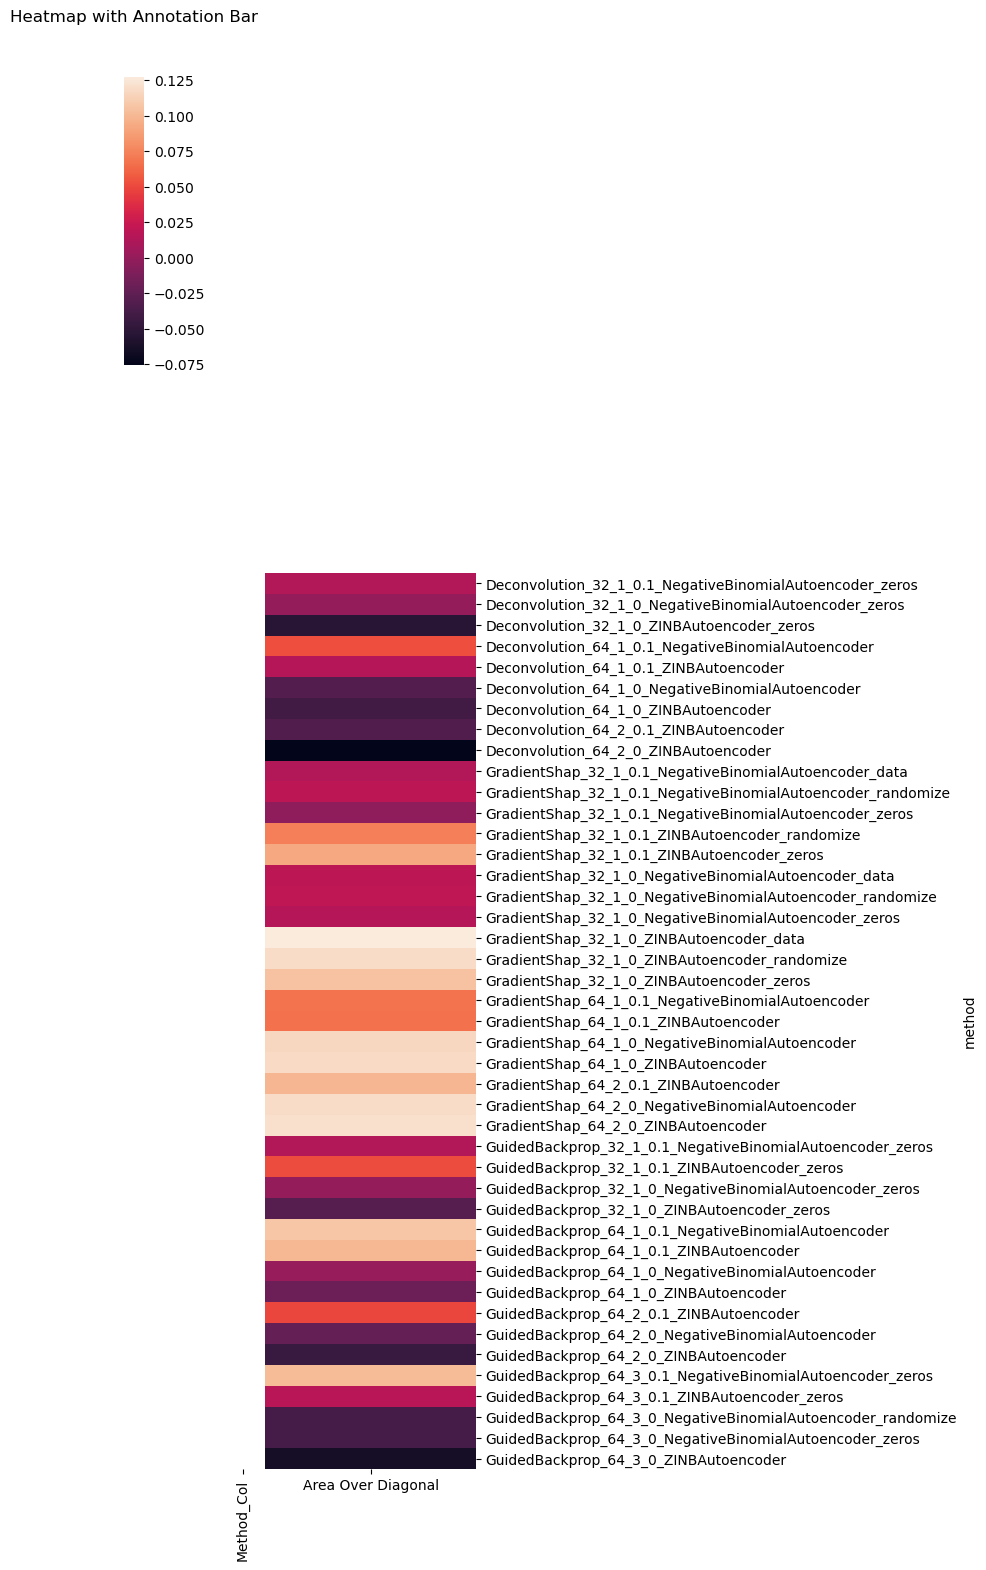

In [220]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


g = sns.clustermap(resagg, 
                   row_colors=row_annotations, 
                   row_cluster=False, 
                   col_cluster=False, 
                   figsize=(4, 16))

plt.title("Heatmap with Annotation Bar", pad=40)
plt.show()